# Supplementary Figures S4–S5: non-spatial model analyses

Start from measured cells and fitted models. Calculate velocity fields,
distribution errors, clone fate, RNA-direction alignment, dense trajectories,
exact GNN messages and LR attribution, then draw S4–S5 from those results.

S4b/e/f use the LR-informed training seeds 42, 43 and 44. S4b averages five
16-cell groupings; S4c/d compare the radius-graph Full and No-interaction models.
S5 uses the cortical LR Full model and its No-interaction comparison.

Run these cells in order with the CytoBridge code folder available. Set
`CYTOBRIDGE_DEVICE` to an available GPU, or `cpu` for a slower run. The default
route recalculates every model-dependent input. Training is optional; the
[training guide](../../reference/figure_sources/nonspatial.md) shows how to
prepare data, build a prior and fit the original state-space architecture.

To reuse an existing numerical analysis, set `CYTOBRIDGE_NONSPATIAL_SOURCES`
to a JSON file containing `weinreb`, `scnt` and `weinreb_field_models` paths.
That shortcut reuses the selected analyses while still calculating S4b.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
run_name = os.environ.get("CYTOBRIDGE_RUN_LABEL", "reader_run")
repo = Path(cb.__file__).resolve().parents[1]

def run(module, *arguments):
    subprocess.run([sys.executable, "-m", module, *map(str, arguments)],
                   cwd=repo, check=True)

import json
from reproduction.nonspatial.inputs import downloaded_sources
from reproduction.nonspatial import analyze

source_override = os.environ.get("CYTOBRIDGE_NONSPATIAL_SOURCES")
reuse_analysis = bool(source_override)
if source_override:
    selected = json.loads(Path(source_override).read_text())
    weinreb, scnt = selected["weinreb"], selected["scnt"]
    field_models = selected["weinreb_field_models"]
else:
    for dataset in ("weinreb", "scnt_cortex"):
        if not (project / "data" / dataset / "full/model/config.yaml").is_file():
            cb.datasets.download(dataset, destination=project)
    paper = project / "data/nonspatial/paper"
    if not (paper / "weinreb/lr_seed44/model/config.yaml").is_file():
        cb.datasets.download("nonspatial", destination=project,
                             kind="nonspatial_paper_inputs.zip")
    weinreb, scnt, field_models = downloaded_sources(project)

wroot, sroot = project / "data/weinreb", project / "data/scnt_cortex"
wfull, wno = wroot / "full/model", wroot / "no_interaction/model"
sfull, sno = sroot / "full/model", sroot / "no_interaction/model"
wexpression, wprior = wroot / "original/Weinreb.h5ad", wroot / "edge_prior/manifest.json"
sexpression = sroot / "original/hvg2000/scnt_cortical_full_total_expression.h5ad"
sprior = sroot / "edge_prior/manifest.json"
sraw = sroot / "original/scnt_cortical_full_20547_raw_counts.h5ad"
spca = sroot / "original/hvg2000/scnt_cortical_full_hvg2000_pca_artifacts.npz"

output = project / "outputs" / ("nonspatial_" + run_name)
output.mkdir(parents=True, exist_ok=False)

## S4b. Evaluate and smooth the fitted velocity field

Evaluate intrinsic drift and the score gradient on every measured 50-PC
state. Evaluate interactions for grouping seeds 0–4, average those fields
within each model, then average the three models. Smooth PC1–PC2 values on
the original 50×50 grid, retaining only the data-supported region.

In [2]:
from reproduction.nonspatial.fields import calculate_weinreb_fields
weinreb["model_grids"] = calculate_weinreb_fields(
    weinreb["prepared_h5ad"], field_models, output / "weinreb_model_fields",
    device=device, grouping_seeds=(0, 1, 2, 3, 4))

## S4c and S5c. Simulate both models and calculate distribution errors

Use each model's matching prepared 50-PC states. Simulate 2,048 particles with
growth, score, noise `sigma=0.1`, integration step `0.05` and 16-cell interaction
groups. Calculate weighted W1/W2 and absolute total-mass error at observed
times, with up to 1,024 points for OT. Each call writes a long
`paired_distribution_metrics.csv`; the adapter below selects its PCA rows.
New stochastic evaluations can differ from the paper's saved values.

In [3]:
if not reuse_analysis:
    wdistribution = analyze.distribution(
        weinreb["prepared_h5ad"], wfull, wno, output / "weinreb_distribution",
        device=device, seed=42)
    sdistribution = analyze.distribution(
        scnt["prepared_h5ad"], sfull, sno, output / "scnt_distribution",
        device=device, seed=42)

## S4d. Calculate clone-fate agreement from ten rollouts

Propagate every day-2 cell to day 6 with step `0.1`, `sigma=0.1` and seeds 0–9.
The original uniform-weighted k=20 classifier is fitted on all measured day-6
cells. Score clone-positive source cells whose lineage occurs at day 6.
Weighted simulated and measured fate distributions are compared per clone.
The call writes each arm's `summary.json` and per-lineage tables.

In [4]:
if not reuse_analysis:
    analyze.clone_fate(
        weinreb["prepared_h5ad"], wfull, wno, output / "weinreb_clone_fate",
        device=device, seeds=tuple(range(10)))

## S5b/d. Calculate dense trajectories and new-RNA direction

Reconstruct the measured new-RNA direction from total/new counts, the saved
PCA transformation and the two-hour labeling interval. Evaluate each model's
field on all measured cells with grouping seeds 101, 202, 303, 404 and 505;
write cellwise cosines and `timewise_scnt_direction_alignment.csv`.

Simulate the Full model at 41 times from 0 to 2, preserving the identities of
2,048 particles. The resulting `full_dense_trajectory.npz` supplies the
finite-difference vectors for the S5b streamlines.

In [5]:
if not reuse_analysis:
    scnt["direction"] = analyze.direction(
        sraw, scnt["prepared_h5ad"], spca, sfull, sno,
        output / "scnt_direction", device=device)
    scnt["full_trajectory"] = analyze.trajectory(
        scnt["prepared_h5ad"], sfull, output / "scnt_trajectory", device=device)

## S4e/f and S5b/e/f. Calculate exact messages and LR attribution

Decompose the learned interaction into sender-type contributions on every
measured cell. Reconstruct LR expression compatibility with the fitted prior,
then calculate `S_AB = D_AB × Q_AB`. Average grouping replicates within each
model before averaging the three Weinreb training seeds.

The calls write `exact_message_summary.csv`, `cell_type_interaction_network.csv`
and `cell_type_pathway_scores.csv.gz`. CellChat remains an independent,
expression-only reference; the model scores and concordance are recalculated.

In [6]:
if not reuse_analysis:
    wattribution = analyze.attribution(
        wexpression, weinreb["prepared_h5ad"], wprior, field_models,
        output / "weinreb_attribution", cell_type_key="Cell type annotation",
        training_seeds=(42, 43, 44), device=device)
    sattribution = analyze.attribution(
        sexpression, scnt["prepared_h5ad"], sprior, [sfull],
        output / "scnt_attribution", cell_type_key="cell_type",
        training_seeds=(42,), device=device)

## Convert the new analysis outputs to panel inputs

Pivot the long distribution tables into the paired PCA comparison. Convert
each arm's clone-fate JSON summary to the three displayed metric rows. Join
new Weinreb GNN messages to the measured CellChat reference, and select the
new cortical message, network and pathway tables. These assignments keep the
calculated outputs connected to the plot below.

In [7]:
from reproduction.nonspatial.adapters import (
    distribution_inputs, clone_fate_input, weinreb_cellchat_input,
)

if not reuse_analysis:
    weinreb["distribution"] = distribution_inputs(
        wdistribution, output / "weinreb_distribution_tables")["distribution"]
    scnt_metrics = distribution_inputs(sdistribution, output / "scnt_distribution_tables")
    scnt["full_distribution"] = scnt_metrics["full_distribution"]
    scnt["no_interaction_distribution"] = scnt_metrics["no_interaction_distribution"]
    weinreb["clone_fate"] = clone_fate_input(
        output / "weinreb_clone_fate", output / "weinreb_clone_fate_panel.csv")
    weinreb["cellchat_joined"] = weinreb_cellchat_input(
        wattribution / "exact_message_summary.csv", weinreb["cellchat_joined"],
        output / "weinreb_cellchat_comparison.csv")
    weinreb["pathways"] = wattribution / "cell_type_pathway_scores.csv.gz"
    scnt["exact_message_summary"] = sattribution / "exact_message_summary.csv"
    scnt["network"] = sattribution / "cell_type_interaction_network.csv"
    scnt["pathways"] = sattribution / "cell_type_pathway_scores.csv.gz"

## Calculate all displayed arrays and tables

Read measured labels and coordinates from H5AD. Calculate cell counts,
distribution changes, clone/direction summaries, trajectory streamlines,
receiver interaction vectors, the displayed network edges and pathway ranks.
Recalculate the CellChat correlations from all eligible directed type pairs
(100/121/121 for Weinreb days 2/4/6; 81 for the final cortical time point).
The existing paper plotting functions keep their original axes and style.

In [8]:
from reproduction.nonspatial.inputs import collect_nonspatial_inputs
from CytoBridge.results import calculate_nonspatial_panels, write_nonspatial_tables

data = collect_nonspatial_inputs(weinreb, scnt, output / "plot_inputs")
panels = calculate_nonspatial_panels(data)
tables = write_nonspatial_tables(panels, output / "figures")
panels.summary

,dataset,metric,value
0,weinreb,cells,49302.000000
1,weinreb,distribution_error_increase_pct,4.479644
2,weinreb,day6_spearman_rho,0.664068
3,scnt,cells,20547.000000
4,scnt,network_spearman_rho,0.752396
5,scnt,direction_mean_wins,3.000000
6,scnt,direction_median_wins,3.000000


## Draw S4–S5 from the new inputs

S4


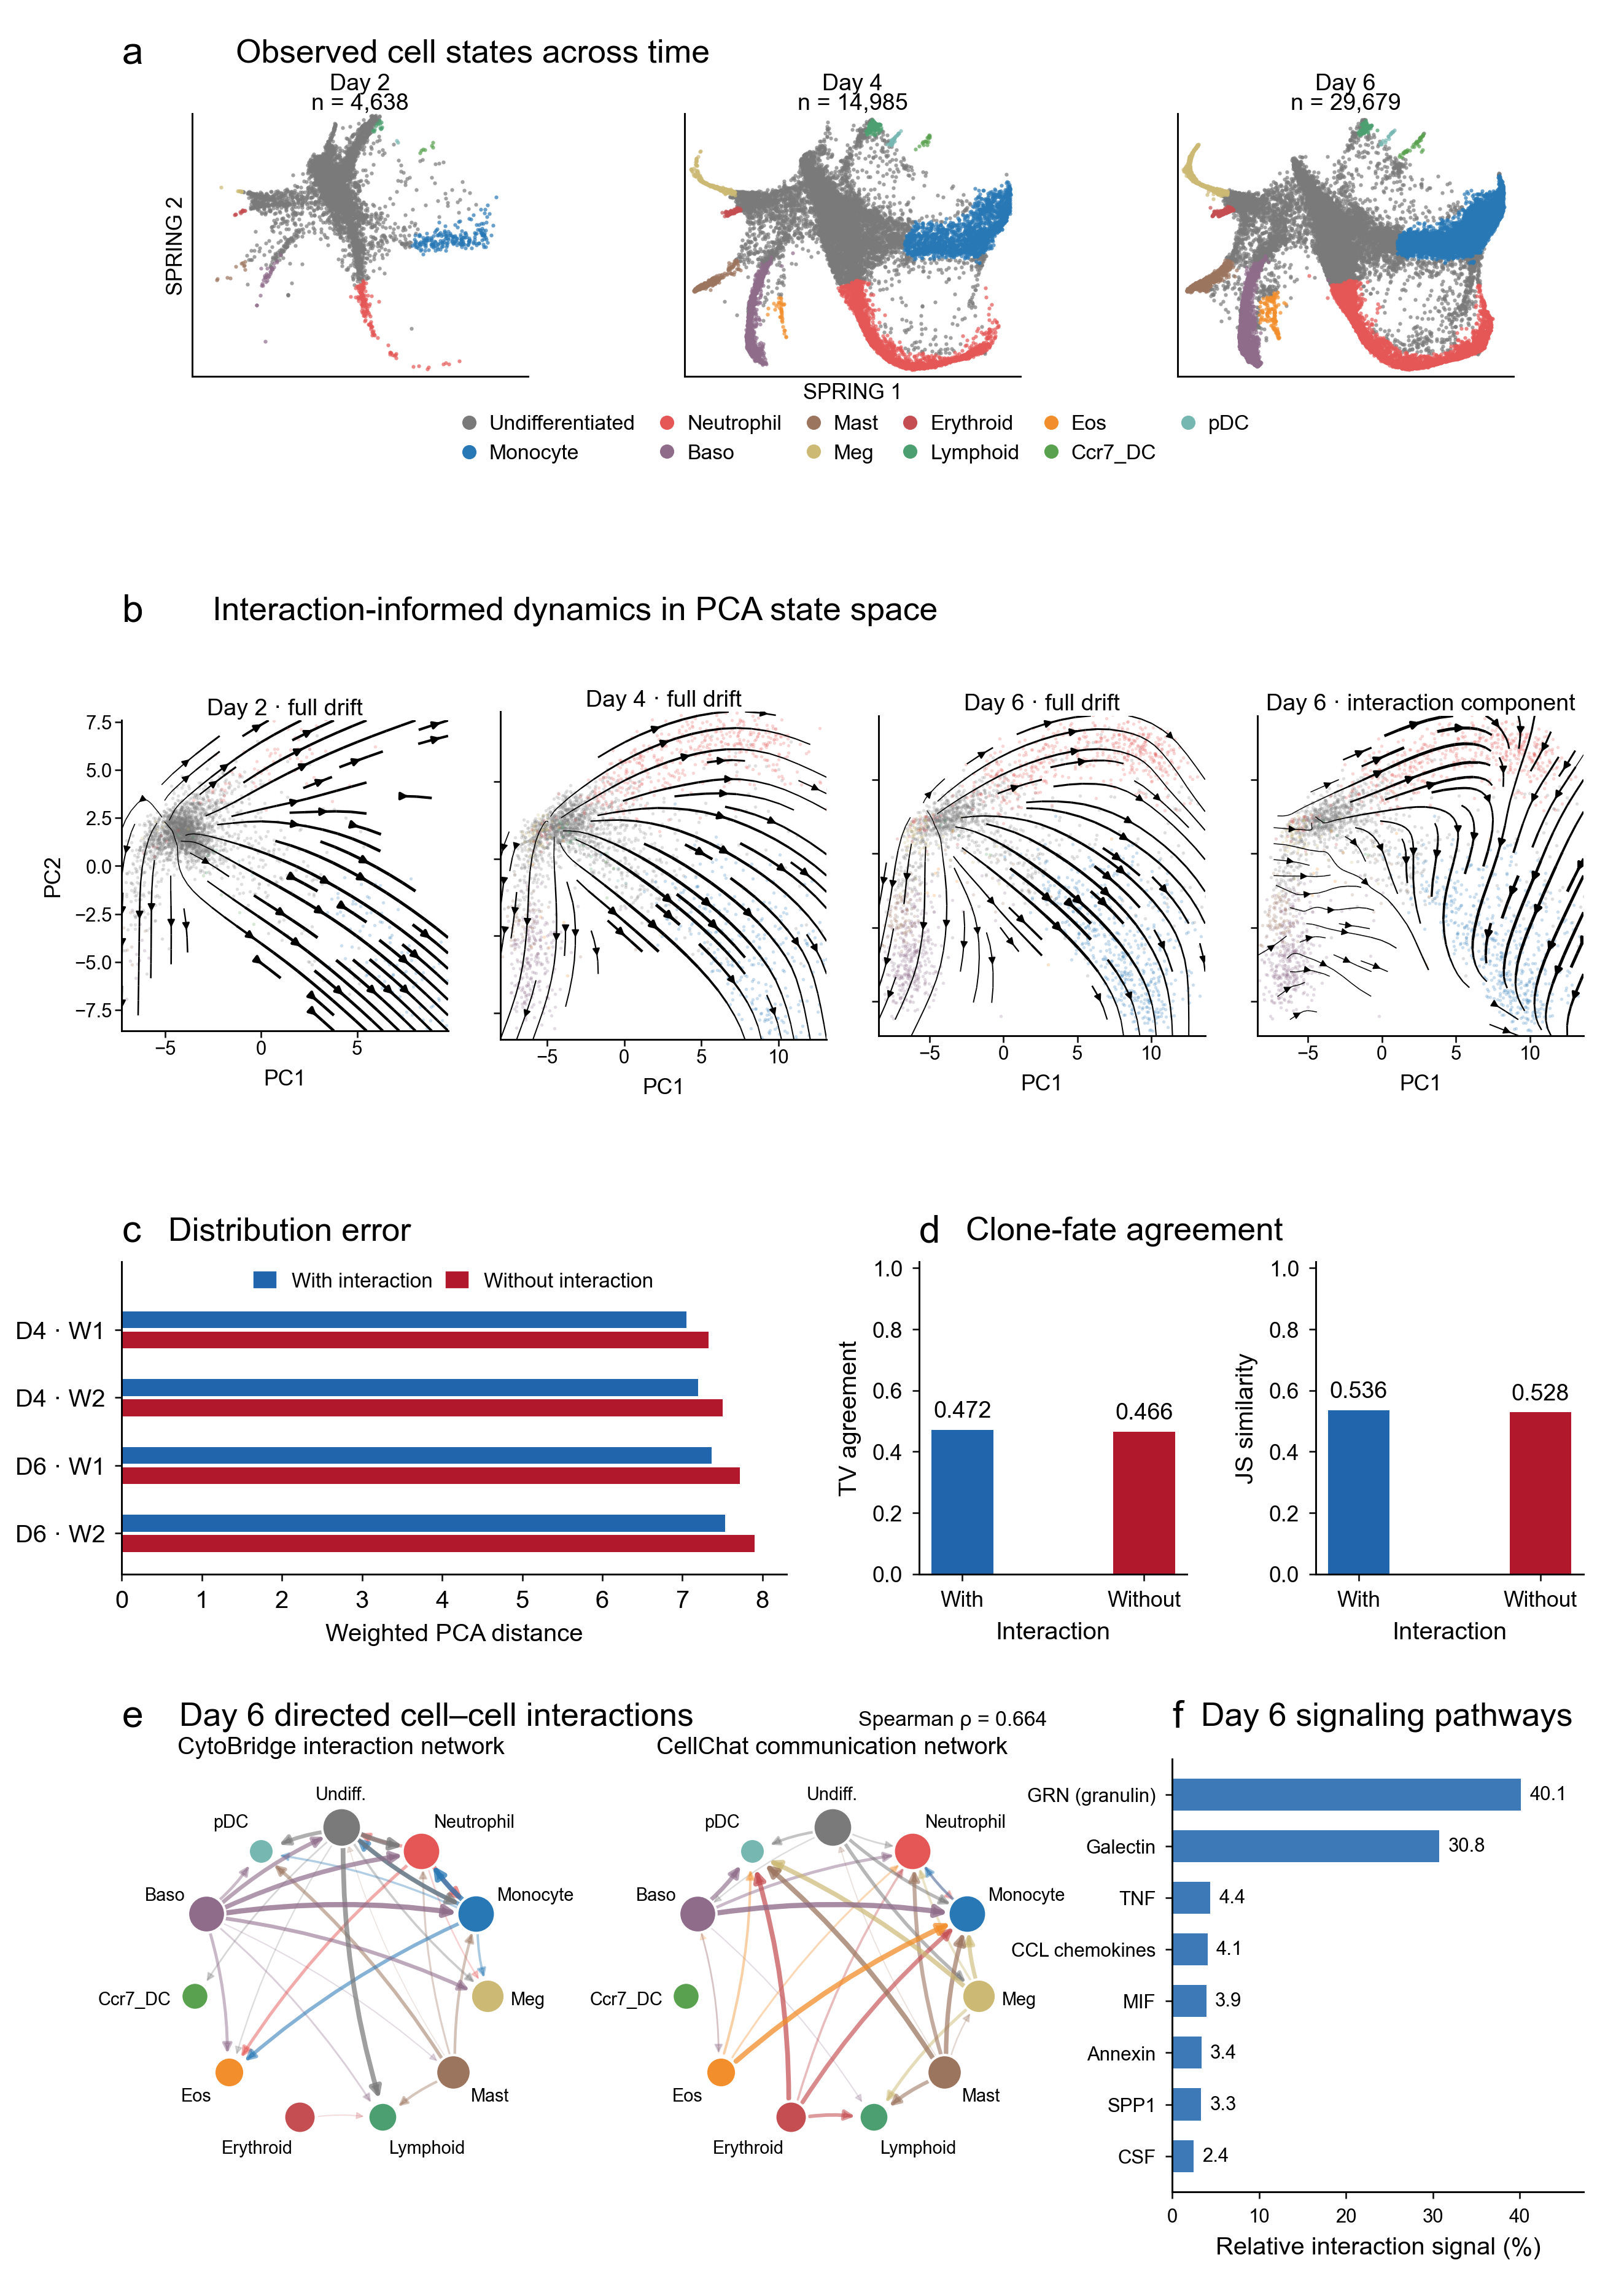

S5


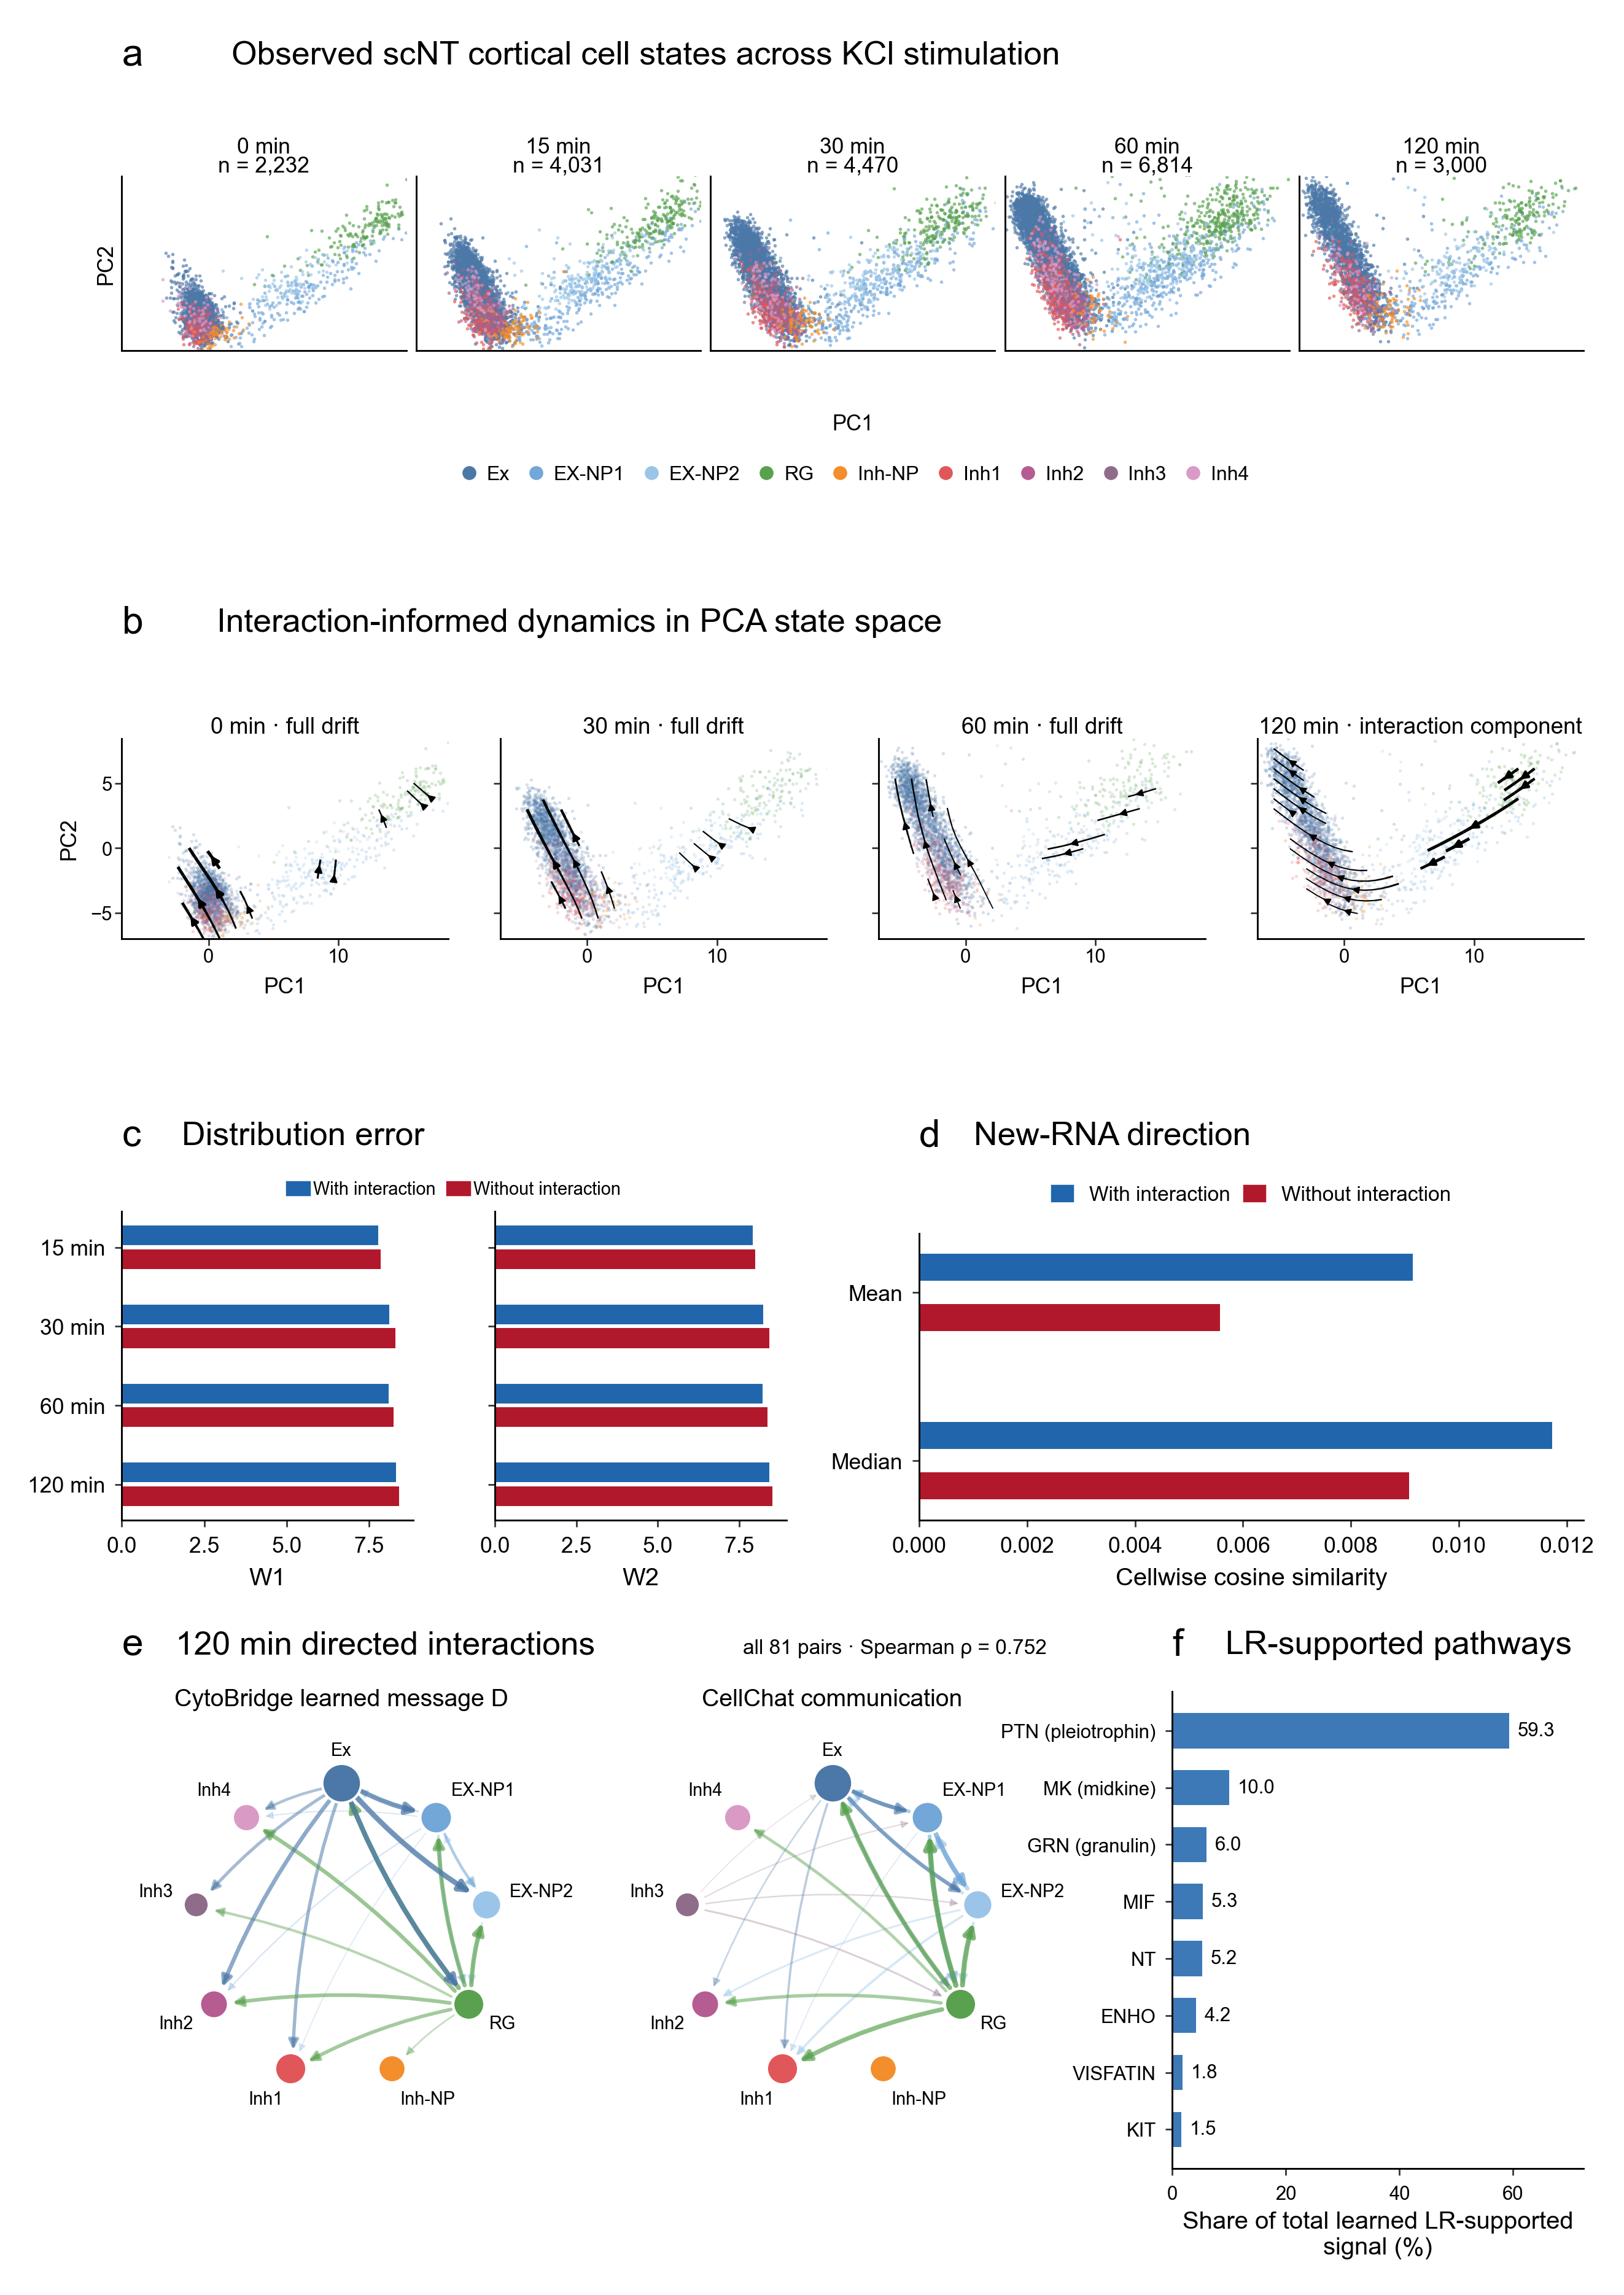

In [9]:
from reproduction.paper_figures import draw_supplementary
figures = draw_supplementary(
    [4, 5], output / "figures", results_dir=data.source_dir,
    data=data, panels=panels)
for name, (_, png) in figures.items():
    print(name.upper())
    display(Image(filename=str(png), width=720))